In [51]:
import json
from pathlib import Path
import random
import numpy as np
import pandas as pd
import itertools
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer
from tqdm.notebook import tqdm
from scipy import stats

input_jsonl = Path("../../data-transformation/ui_captions_dataset_v2.jsonl")
num_pairs_to_generate = 50000 
batch_size = 512
z_threshold = 2

model = SentenceTransformer('all-MiniLM-L6-v2', device="cuda")

In [41]:
valid_captions = []
with open(input_jsonl, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip(): continue
        data = json.loads(line.strip())
        caption = data.get("caption", "").strip()
        if caption and caption.upper() != "NOISY UI":
            valid_captions.append(caption.replace('High-fidelity mobile UI, ', ''))

valid_captions = list(set(valid_captions))
print(f"Total de legendas únicas válidas: {len(valid_captions)}")

# Negative sampling
list_a, list_b = [], []
for _ in range(num_pairs_to_generate):
    idx1, idx2 = random.sample(range(len(valid_captions)), 2)
    list_a.append(valid_captions[idx1])
    list_b.append(valid_captions[idx2])
print(f"{num_pairs_to_generate} pares aleatórios descombinados gerados")

Total de legendas únicas válidas: 11349
50000 pares aleatórios descombinados gerados


In [42]:
neg_similarities = []
print("Calculando embeddings e similaridade de cosseno...")
for i in tqdm(range(0, num_pairs_to_generate, batch_size)):
    batch_a = list_a[i : i + batch_size]
    batch_b = list_b[i : i + batch_size]
    
    emb_a = model.encode(batch_a, convert_to_tensor=True, show_progress_bar=False)
    emb_b = model.encode(batch_b, convert_to_tensor=True, show_progress_bar=False)
    
    cos_sims = F.cosine_similarity(emb_a, emb_b)
    neg_similarities.extend(cos_sims.cpu().tolist())


Calculando embeddings e similaridade de cosseno...


  0%|          | 0/98 [00:00<?, ?it/s]

In [52]:
neg_sim_array = np.array(neg_similarities)
z_scores = np.abs(stats.zscore(neg_sim_array))
neg_sim_array = neg_sim_array[z_scores < z_threshold]

mean_sim = np.mean(neg_sim_array)
p99 = np.percentile(neg_sim_array, 99)
p95 = np.percentile(neg_sim_array, 95)
p75 = np.percentile(neg_sim_array, 75)
p50 = np.percentile(neg_sim_array, 50)
p25 = np.percentile(neg_sim_array, 25)
p10 = np.percentile(neg_sim_array, 10)
p5 = np.percentile(neg_sim_array, 5)

print("\n" + "="*50)
print(" Estatísticas do Ruído de Domínio (r_min) ")
print("="*50)
print(f"Média        : {np.mean(neg_sim_array):.4f}")
print(f"Percentil 99 : {p99:.4f}")
print(f"Percentil 95 : {p95:.4f}")
print(f"Percentil 75 : {p75:.4f}")
print(f"Mediana (P50): {p50:.4f}")
print(f"Percentil 25 : {p25:.4f}")
print(f"Percentil 10 : {p10:.4f}")
print(f"Percentil 05 : {p5:.4f}")
print("="*50)


 Estatísticas do Ruído de Domínio (r_min) 
Média        : 0.4004
Percentil 99 : 0.5956
Percentil 95 : 0.5534
Percentil 75 : 0.4635
Mediana (P50): 0.3990
Percentil 25 : 0.3354
Percentil 10 : 0.2821
Percentil 05 : 0.2529


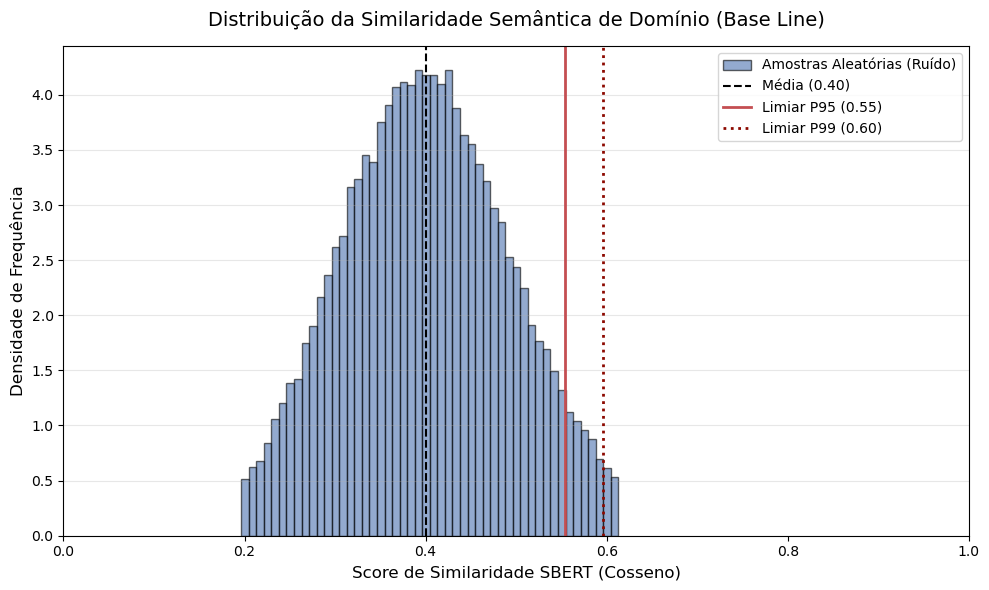

In [53]:
plt.figure(figsize=(10, 6))

# Plotar o histograma principal
counts, bins, patches = plt.hist(
    neg_sim_array, 
    bins=50, 
    density=True, 
    alpha=0.6, 
    color='#4C72B0', 
    edgecolor='black',
    label='Amostras Aleatórias (Ruído)'
)

# Adicionar linhas verticais para os percentis
plt.axvline(mean_sim, color='black', linestyle='--', linewidth=1.5, label=f'Média ({mean_sim:.2f})')
plt.axvline(p95, color='#C44E52', linestyle='-', linewidth=2, label=f'Limiar P95 ({p95:.2f})')
plt.axvline(p99, color='#8C0900', linestyle=':', linewidth=2, label=f'Limiar P99 ({p99:.2f})')

# Formatação acadêmica do gráfico
plt.title('Distribuição da Similaridade Semântica de Domínio (Base Line)', fontsize=14, pad=15)
plt.xlabel('Score de Similaridade SBERT (Cosseno)', fontsize=12)
plt.ylabel('Densidade de Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper right', frameon=True, fontsize=10)
plt.xlim(0, 1.0) # Força o eixo X a mostrar o espectro completo do SBERT

# Ajustar layout e exibir
plt.tight_layout()
plt.show()

In [ ]:
df = pd.DataFrame({'caption_a': list_a, 'caption_b': list_b, 'similarity_score': neg_similarities})
df['similarity_score'] = df['similarity_score'].round(4)
df.to_csv("sbert_lower_bound_results.csv", index=False)

### Avaliação para o r_max 

Compara variantes de captions geradas com diferentes seed para uma mesma imagem

In [46]:
input_jsonl = "sbert_r_max_samples.jsonl"
batch_size = 512

print("Lendo o dataset de variações e gerando pares combinatórios...")
list_a = []
list_b = []
image_tracker = []

with open(input_jsonl, 'r', encoding='utf-8') as f:
    for line in f:
        if not line.strip(): continue
        data = json.loads(line.strip())
        
        filename = data.get("filename")
        variations = data.get("variations", [])
        
        # Extrair apenas os textos das legendas que não deram erro
        captions = [v["generated_caption"].replace('High-fidelity mobile UI, ', '') for v in variations if v.get("generated_caption")]
        
        if len(captions) < 2:
            continue
            
        # itertools.combinations cria todos os pares únicos (sem repetição e sem espelhamento)
        # Para 20 legendas, isso gera 190 pares por imagem
        for cap1, cap2 in itertools.combinations(captions, 2):
            list_a.append(cap1)
            list_b.append(cap2)
            image_tracker.append(filename)

total_pairs = len(list_a)
print(f"Total de imagens processadas: {len(set(image_tracker))}")
print(f"Total de pares par-a-par gerados: {total_pairs}")

Lendo o dataset de variações e gerando pares combinatórios...
Total de imagens processadas: 44
Total de pares par-a-par gerados: 8360


In [47]:
similarities = []

for i in tqdm(range(0, total_pairs, batch_size), desc="Calculando embeddings e similaridade de cosseno"):
    batch_a = list_a[i : i + batch_size]
    batch_b = list_b[i : i + batch_size]
    
    emb_a = model.encode(batch_a, convert_to_tensor=True, show_progress_bar=False)
    emb_b = model.encode(batch_b, convert_to_tensor=True, show_progress_bar=False)
    
    cos_sims = F.cosine_similarity(emb_a, emb_b)
    similarities.extend(cos_sims.cpu().tolist())

Calculando embeddings e similaridade de cosseno:   0%|          | 0/17 [00:00<?, ?it/s]

In [55]:
sim_array = np.array(similarities)
z_scores = np.abs(stats.zscore(sim_array))
sim_array = sim_array[z_scores < z_threshold]

p99 = np.percentile(sim_array, 99)
p95 = np.percentile(sim_array, 95)
p75 = np.percentile(sim_array, 75)
p50 = np.percentile(sim_array, 50)
p25 = np.percentile(sim_array, 25)
p10 = np.percentile(sim_array, 10)
p15 = np.percentile(sim_array, 15)
p5 = np.percentile(sim_array, 5)

print("\n" + "="*50)
print(" ESTATÍSTICAS DO LIMITE SUPERIOR EMPÍRICO (r_max) ")
print("="*50)
print(f"Média        : {np.mean(sim_array):.4f}")
print(f"Percentil 99 : {p99:.4f}")
print(f"Percentil 95 : {p95:.4f}")
print(f"Percentil 75 : {p75:.4f}")
print(f"Mediana (P50): {p50:.4f}")
print(f"Percentil 25 : {p25:.4f}")
print(f"Percentil 15 : {p15:.4f}")
print(f"Percentil 10 : {p10:.4f}")
print(f"Percentil 05 : {p5:.4f}")
print("="*50)


 ESTATÍSTICAS DO LIMITE SUPERIOR EMPÍRICO (r_max) 
Média        : 0.9199
Percentil 99 : 0.9967
Percentil 95 : 0.9873
Percentil 75 : 0.9618
Mediana (P50): 0.9302
Percentil 25 : 0.8871
Percentil 15 : 0.8591
Percentil 10 : 0.8390
Percentil 05 : 0.8153


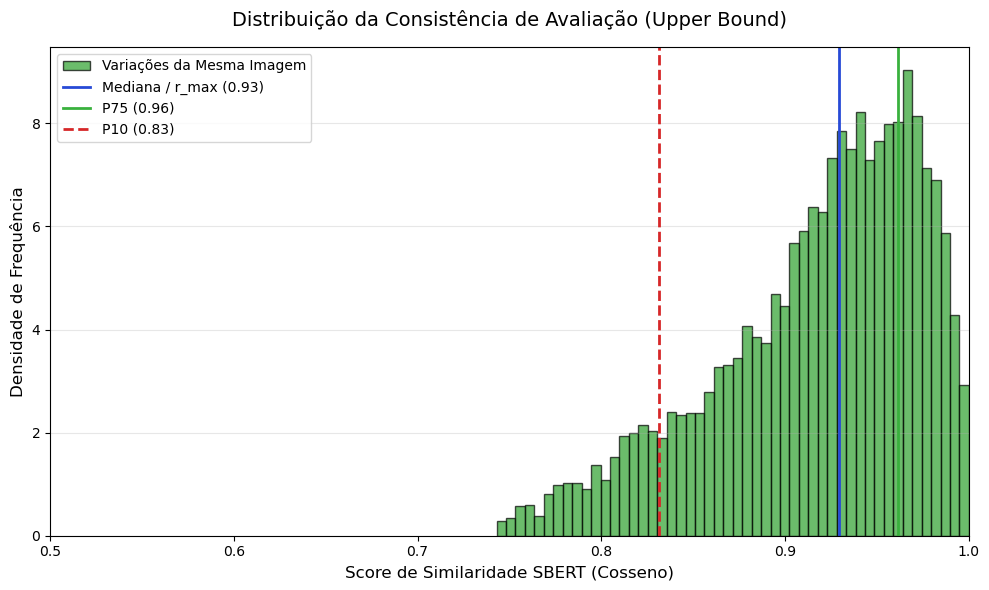

In [49]:
plt.figure(figsize=(10, 6))

counts, bins, patches = plt.hist(
    sim_array, 
    bins=50, 
    density=True, 
    alpha=0.7, 
    color='#2CA02C', # Verde para indicar "sucesso/acerto"
    edgecolor='black',
    label='Variações da Mesma Imagem'
)

# Adicionar linhas verticais para as estatísticas chave
plt.axvline(p50, color="#274AD6", linestyle='-', linewidth=2, label=f'Mediana / r_max ({p50:.2f})')
plt.axvline(p75, color="#39B13D", linestyle='-', linewidth=2, label=f'P75 ({p75:.2f})')
plt.axvline(p10, color='#D62728', linestyle='--', linewidth=2, label=f'P10 ({p10:.2f})')

plt.title('Distribuição da Consistência de Avaliação (Upper Bound)', fontsize=14, pad=15)
plt.xlabel('Score de Similaridade SBERT (Cosseno)', fontsize=12)
plt.ylabel('Densidade de Frequência', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.legend(loc='upper left', frameon=True, fontsize=10)

# Forçar o eixo X a mostrar o topo da escala
plt.xlim(0.5, 1.0) 

plt.tight_layout()
plt.show()

In [ ]:
df_results = pd.DataFrame({
    'image': image_tracker,
    'similarity_score': similarities
})
df_results['similarity_score'] = df_results['similarity_score'].round(4)
df_results.to_csv("sbert_upper_bound_results.csv", index=False)